In [2]:
import torch
import numpy
import matplotlib.pyplot as plt
import os

In [3]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [4]:
if not os.path.exists('models'):
    os.mkdir('models')

# LFY034
## Encoder-Decoder
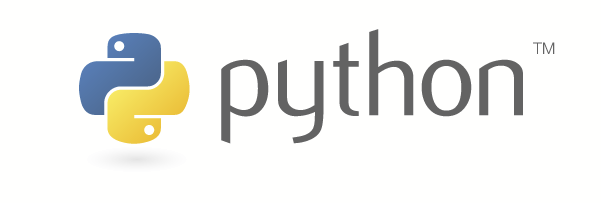
Daniel Midtvedt

# Encoder-Decoder - ett sätt att komprimera data på och mycket mer
<img src="../images/decoderencoder.png" width=60%/>


- **Encoder:** Ett nätverk som tar emot högdimensionell inmatning och komprimerar den till en lågdimensionell (latent-) representation (latent space). Encodern lär sig extrahera viktiga drag från datan.

- **Decoder:** Ett nätverk som tar emot den komprimerade latent-representationen och transformerar den till en ny högdimensionell representation

- **Latent Space:** Den komprimerade representationen av datan kallas latent space. 

- **Definition:** Autoencoders är en typ av encoder-decoder nätverk som tränas för att återskapa sin inmatning så exakt som möjligt. De kan tränas på data utan annotering.

- **Användningsområden:**
  - **Dimensionsreduktion:** Används för att minska antalet dimensioner i datan.
  - **Feature Learning:** Lär sig automatiskt viktiga drag eller features i datan.
  - **Bildgenerering och Restaurering:** Kan användas för att generera nya bilder eller återskapa skadade bilder.
  - **Outliersdetektering** Hitta observationer som sticker ut från mängden.
  - **Brusreducering** Reducera mängden brus i data.
  - **Språkhantering och översättning** Kan användas för att transformera en mening i ett språk till motsvarande mening i ett annat språk

## MNIST
![MNIST2](../images/mnist.png)

<img src="../images/mnist_2digits.png"/>

### Dataformat
* $ 28 \times 28$ pixlar
* Gråskala, värden mellan 0 och 1

## Läsa in data via torchvision

In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='../datasets', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='../datasets', train=False, transform=transform)

In [7]:
print('Antalet träningsexempel:', len(train_dataset))
print('Antalet testexempel:', len(test_dataset))

Antalet träningsexempel: 60000
Antalet testexempel: 10000


In [9]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=True)

In [10]:
# Varje element i train_loader är en tupel med en samling (batch) bilder tillsammans 
examples = iter(train_loader)
bilder, siffror = next(examples)

tensor(0.)
tensor(0.)
tensor(0.)


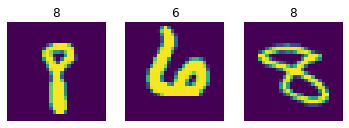

In [11]:
# Visa några exempel

# zip(bilder[:3], siffror[:3]) skapar en lista av tupler [(bild1, siffra1), (bild2, siffra2), ...]
for n, (bild, siffra) in enumerate(zip(bilder[3:6], siffror[3:6])):
    plt.subplot(1, 3, n + 1)
    plt.imshow(bild[0])
    plt.axis("off")
    plt.title(siffra.item())
    print(bild[0,0,0])

## Definera en autoencoderarkitektur
Vi skapar en klass som ärver från `nn.Module` och som består av två delar: en encoder och en decoder.

In [12]:
# Definiera autoencoder-modellen
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 2)  # 2-dimensionell latent space för enkel visualisering
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 12), # 2 ---> 12
            nn.ReLU(),
            nn.Linear(12, 64), # 12 ---> 64
            nn.ReLU(),
            nn.Linear(64, 128), # 64 ---> 128
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Sigmoid för att generera värden mellan 0 och 1
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.encoder(x) # 2-dimensionell representation
        x = self.decoder(x) # 28*28-dimensionell representation
        x = x.view(-1, 1, 28, 28)
        return x

## Definera en autoencoderarkitektur fast som istället är ett 2DCNN

Då vi arbetar med bilddata kan det vara fördelaktigt att använda en 2DCNN arkitektur. Vi skapar även här en klass som ärver från `nn.Module` och som består av två delar: en encoder och en decoder.

In [ ]:
# Definiera 2D autoencoder-modellen med 2D-convolutions
class Autoencoder2DConv(nn.Module):
    def __init__(self):
        super(Autoencoder2DConv, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 1x28x28 -> 16x14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 16x14x14 -> 32x7x7
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7),  # 32x7x7 -> 64x1x1
            nn.Flatten(),
            nn.Linear(64, 2)  # 2-dimensionell latent space för enkel visualisering
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.Unflatten(1, (64, 1, 1)),  # Reshape till 64x1x1 och två dimensioner
            nn.ConvTranspose2d(64, 32, kernel_size=7),  # 64x1x1 -> 32x7x7
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32x7x7 -> 16x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x14x14 -> 1x28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x) #2-dimensionell representation
        x = self.decoder(x) # 28X28 pixlar
        return x

In [13]:
# Skapa en instans av autoencoder
autoencoder = Autoencoder()

#Läs in modellen från fil om den finns
if os.path.isfile('models/autoencoder.pth'):
    print('Läser in modellen från fil')
    try:
        autoencoder.load_state_dict(torch.load('models/autoencoder.pth'))
    except:
        print('Kunde inte läsa in modellen från fil')
        pass

Läser in modellen från fil


# Träna modellen
Vi tränar modellen för att rekonstruera sin egen input. Dvs. indatan ska komprimeras sen rekonstrueras så att den är så lik sig själv som möjligt.

In [14]:
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# Antalet epoker. Vi sätter till 1, för vi har redan tränat modellen.
num_epochs = 1

for epoch in range(num_epochs):
    for data in train_loader:
        img, _ = data
        optimizer.zero_grad()
        outputs = autoencoder(img) # Ny 28*28-pixelbild
        loss = criterion(outputs, img)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

#Spara modellen
torch.save(autoencoder.state_dict(), 'models/autoencoder.pth')

Epoch [1/1], Loss: 0.0383


## Visualisera några rekonstruktioner

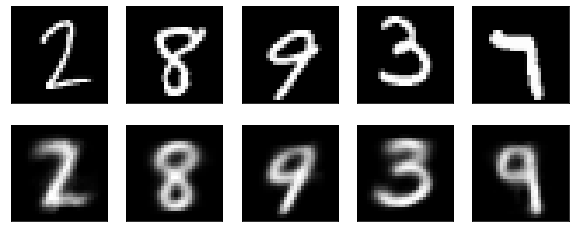

In [16]:
# Testa autoencoder på testdata och visualisera resultatet
with torch.no_grad():
    for data in test_loader:
        img, _ = data
        reconstructed_img = autoencoder(img)
        break

# Jämför några bilder med deras återskapade versioner
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Originalbild
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(img[i].numpy().squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Återskapad bild
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_img[i].numpy().squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## Visualisera latent space / komprimeringen

* Latent space är här endast 2 tal som har blivit "optimerade" via vår träning.
* Encodern har tagit som input 1 bild och manipulerat den tills bara 2 tal återstår, sen har decodern rekonstruerat bilden från dessa två tal.
* På ett sätt kan man säga att nätverket har lärt sig en kompression av bilden.

In [17]:
#Prediktera latent space för testdata
ENC = []
LAB = []
with torch.no_grad():
    for data in test_loader:
        img, lab = data
        enc = autoencoder.encoder(img.view(-1, 28 * 28)) #Vi kommer här åt den komprimerade datan från encodern.
        ENC.append(enc)
        LAB.append(lab)
ENC = torch.cat(ENC, dim=0)
LAB = torch.cat(LAB, dim=0).numpy()

### Visualisera latent space i 2D

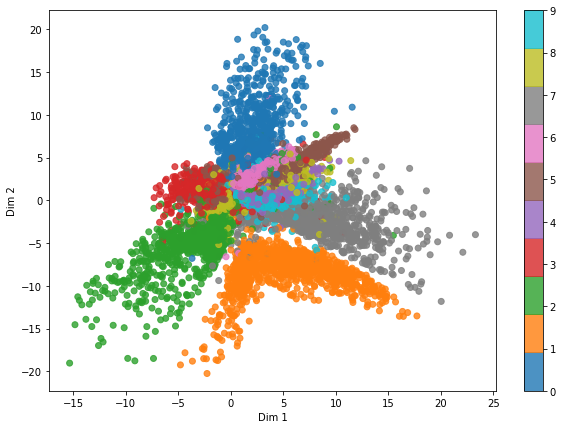

In [18]:
plt.figure(figsize=(10, 7))
plt.scatter(ENC[:, 0], ENC[:, 1], c=LAB, cmap='tab10', alpha=0.8)
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.colorbar()
plt.show()

## Generera ny data från latent space / kompression
Vår decoder kan användas för att generera "nya" bilder via input av två tal.

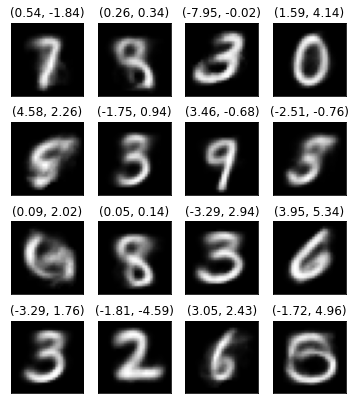

In [19]:
n = 16

plt.figure(figsize=(6, 7))
for i in range(n):
    # Återskapad bild
    ax = plt.subplot(4, 4, i + 1)
    z = torch.randn(1, 2)*3 # Slumpmässiga tal
    
    img = autoencoder.decoder(z)
    img = img.detach()
    img = img.view(-1, 1, 28, 28)
    
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'({z[0,0]:.2f}, {z[0,1]:.2f})')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


## Definera en autoencoderarkitektur fast som istället är ett 2DCNN

Då vi arbetar med bilddata kan det vara fördelaktigt att använda en 2DCNN arkitektur. Vi skapar även här en klass som ärver från `nn.Module` och som består av två delar: en encoder och en decoder.

In [20]:
# Definiera 2D autoencoder-modellen med 2D-convolutions
class Autoencoder2DConv(nn.Module):
    def __init__(self):
        super(Autoencoder2DConv, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 1x28x28 -> 16x14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 16x14x14 -> 32x7x7
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7),  # 32x7x7 -> 64x1x1
            nn.Flatten(),
            nn.Linear(64, 2)  # 2-dimensionell latent space för enkel visualisering
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.Unflatten(1, (64, 1, 1)),  # Reshape till 64x1x1 och två dimensioner
            nn.ConvTranspose2d(64, 32, kernel_size=7),  # 64x1x1 -> 32x7x7
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32x7x7 -> 16x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x14x14 -> 1x28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [21]:
# Skapa en instans av autoencoder
autoencoder2d = Autoencoder2DConv()

#Läs in modellen från fil om den finns
if os.path.isfile('models/autoencoder2d.pth'):
    print('Laddar modell från fil')
    try:
        autoencoder2d.load_state_dict(torch.load('models/autoencoder2d.pth'))
    except:
        print('Kunde inte ladda modell från fil')

Laddar modell från fil


## Träna modellen
Vi tränar modellen för att rekonstruera sin egen input. Dvs. indatan ska komprimeras sen rekonstrueras så att den är så lik sig själv som möjligt.

In [22]:
criterion = nn.MSELoss() #MSE förlust
optimizer = optim.Adam(autoencoder2d.parameters(), lr=0.001)

# Antalet epoker. Vi sätter till 1, för vi har redan tränat modellen.
num_epochs = 0

for epoch in range(num_epochs):
    for data in train_loader:
        img, _ = data
        optimizer.zero_grad()
        outputs = autoencoder2d(img)
        loss = criterion(outputs, img)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

#Spara modellen
torch.save(autoencoder2d.state_dict(), 'models/autoencoder2d.pth')

# Visualisera några rekonstruktioner

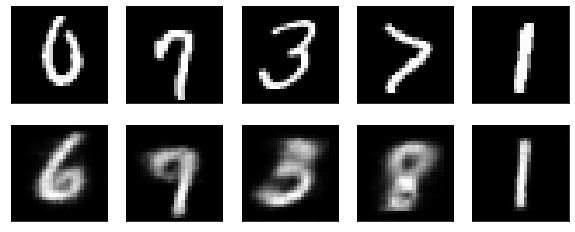

In [25]:
# Testa autoencoder på testdata och visualisera resultatet
with torch.no_grad():
    for data in test_loader:
        img, _ = data
        reconstructed_img = autoencoder2d(img)
        break

# Jämför några bilder med deras återskapade versioner
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Originalbild
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(img[i].numpy().squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Återskapad bild
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_img[i].numpy().squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## Visualisera latent-space

In [26]:
#Prediktera latent space för testdata
ENC = []
LAB = []
with torch.no_grad():
    for data in test_loader:
        img, lab = data
        enc = autoencoder2d.encoder(img)
        ENC.append(enc)
        LAB.append(lab)
ENC = torch.cat(ENC, dim=0)
LAB = torch.cat(LAB, dim=0).numpy()

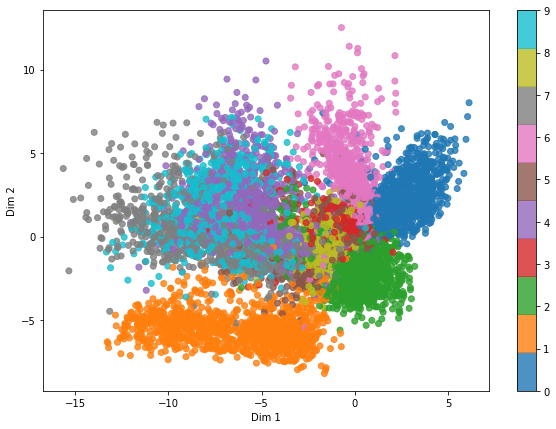

In [27]:
#Visualisera latent space i 2D
plt.figure(figsize=(10, 7))
plt.scatter(ENC[:, 0], ENC[:, 1], c=LAB, cmap='tab10', alpha=0.8)
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.colorbar()
plt.show()

# Generera ny data

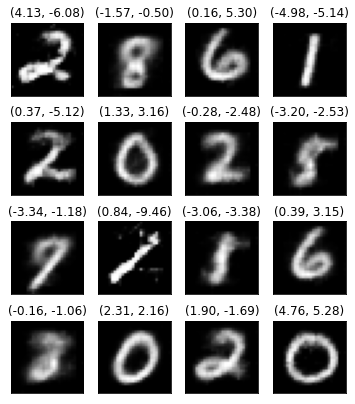

In [28]:
n = 16
plt.figure(figsize=(6, 7))
for i in range(n):
    # Återskapad bild
    ax = plt.subplot(4, 4, i + 1)
    z = torch.randn(1, 2)*3 # Slumpmässiga tal
    
    img = autoencoder2d.decoder(z)
    img = img.detach()
    img = img.view(-1, 1, 28, 28)
    
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'({z[0,0]:.2f}, {z[0,1]:.2f})')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

## För yterliggare abstraktion finns det olika sätt att "bearbeta" latent space / kompressionen på

<img src="../images/decoderencoder_cases.png" width=60%/>

* Olika antal neuroner i latent space. Inget krav att man har 2 tal.
* Olika sampling metoder. Man kan till exempel dra värden från en distribution. Kallas för Variational Autoencoder och var den första generationen av generativ AI

## Definera en variational autoencoder (VAE) arkitektur

En VAE är en vidareutveckling av en autoencoder, där en autoencoder består av två delar:

* **Encoder**: Komprimerar data till en mindre dimension (latent space).
* **Decoder**: Återskapar data från den latenta representationen.

Skillnad mot vanlig autoencoder: I en VAE representerar den latenta rymden sannolikhetsfördelningar istället för fasta punkter. Under träning, skapas nya bilder genom att dra punkter från latent space slumpmässigt enligt en distribution som encoder-delen lär sig. På det viset tvingas autoencodern att placera liknande bilder nära varandra i latent space.

In [29]:
#Definiera variational autoencoder-modell
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 1x28x28 -> 16x14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 16x14x14 -> 32x7x7
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7),  # 32x7x7 -> 64x1x1
            nn.Flatten(),
            nn.Linear(64, 4)  # 4-dimensionell latent space: 2 medelvärden och 2 standardavvikelser ---> 2 tal
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.Unflatten(1, (64, 1, 1)),  # Reshape till 64x1x1
            nn.ConvTranspose2d(64, 32, kernel_size=7),  # 64x1x1 -> 32x7x7
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32x7x7 -> 16x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x14x14 -> 1x28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        mu = x[:, :2]
        logvar = x[:, 2:]
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        x = self.decoder(z)
        return x, mu, logvar
    
    def kl_loss(self, mu, logvar):
        return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    

# Skapa en instans av autoencoder
vae = VAE()

#Läs in modellen från fil om den finns
if os.path.isfile('models/vae.pth'):
    print('Laddar modell från fil')
    try:
        vae.load_state_dict(torch.load('models/vae.pth'))
    except:
        print('Kunde inte ladda modell från fil')

Laddar modell från fil


# Träna modellen
Vi tränar modellen för att rekonstruera sin egen input. Dvs. indatan ska komprimeras sen rekonstrueras så att den är så lik sig själv som möjligt. I mellansteget så komprimeras bilden av encodern till 4 tal, som sedan bestämmer värdena till en normalfördelning som vi drar 2 tal ifrån och matar in till decodern. Vi använder också en mer komplicerad förlustfunktion där vi också tar hänsyn till att vår kompression är normalfördelad.

In [30]:
def loss_function(recon_x, x, mu, logvar):
    MSE = criterion(recon_x, x)
    KLD = vae.kl_loss(mu, logvar)*1e-4
    return MSE + KLD

criterion = nn.MSELoss() #MSE förlust
optimizer = optim.Adam(vae.parameters(), lr=0.001)

# Träna autoencoder
num_epochs = 0

for epoch in range(num_epochs):
    for data in train_loader:
        img, _ = data
        optimizer.zero_grad()
        outputs, mu, logvar = vae(img)
        loss = loss_function(outputs, img, mu, logvar)
        loss.backward()
        optimizer.step()
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

#Spara modellen  
torch.save(vae.state_dict(), 'models/vae.pth')
    

# Visualisera några rekonstruktioner

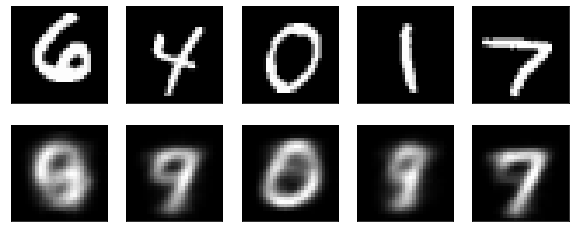

In [34]:
# Testa autoencoder på testdata och visualisera resultatet
with torch.no_grad():
    for data in test_loader:
        img, _ = data
        reconstructed_img, mu, logvar = vae(img)
        break

# Jämför några bilder med deras återskapade versioner
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Originalbild
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(img[i].numpy().squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Återskapad bild
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_img[i].numpy().squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

# Visualisera latent-space

In [35]:
# Visualisera latent-space
ENC = []
LAB = []
with torch.no_grad():
    for data in test_loader:
        img, lab = data
        enc = vae.encoder(img)[:, :2]
        ENC.append(enc)
        LAB.append(lab)
        
ENC = torch.cat(ENC, dim=0)
LAB = torch.cat(LAB, dim=0).numpy()


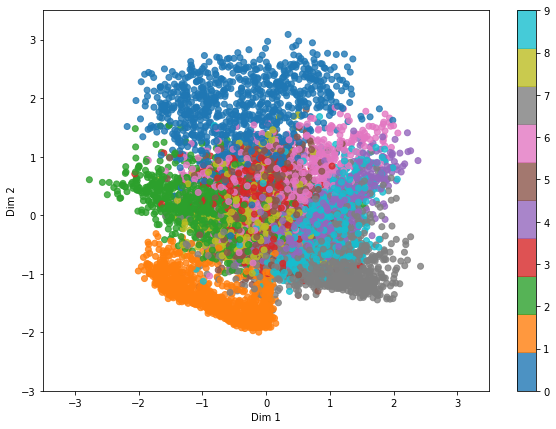

In [37]:
#Visualisera latent space i 2D
plt.figure(figsize=(10, 7))
plt.scatter(ENC[:, 0], ENC[:, 1], c=LAB, cmap='tab10', alpha=0.8)
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.xlim(-3.5, 3.5)
plt.ylim(-3, 3.5)
plt.colorbar()
plt.show()

# Generera ny data

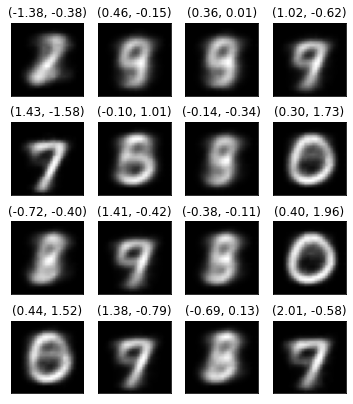

In [39]:
n = 16
plt.figure(figsize=(6, 7))
for i in range(n):
    # Återskapad bild
    ax = plt.subplot(4, 4, i + 1)
    z = torch.randn(1, 2) # Slumpmässiga tal
    
    img, = vae.decoder(z)
    img = img.detach()
    img = img.view(-1, 1, 28, 28)
    
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'({z[0,0]:.2f}, {z[0,1]:.2f})')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

### U-Nets för mer detaljrik bildgenerering
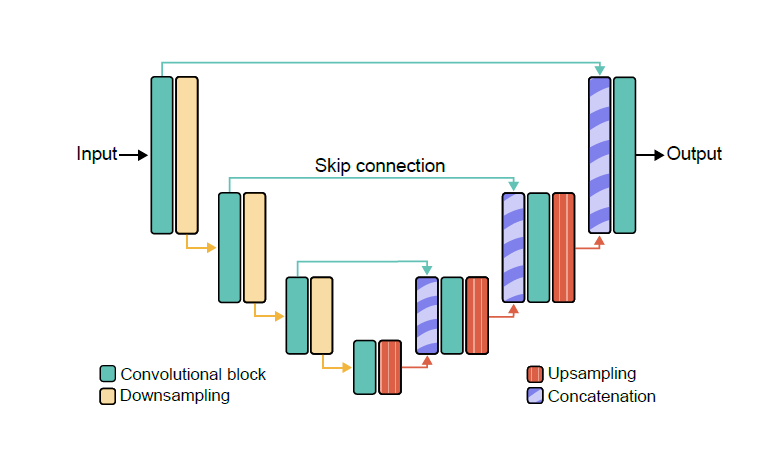

Samma struktur, men nu matas decoder-delen med data från varje steg i encoder-delen. Det gör det möjligt att göra mer detaljrik rekonstruktion.
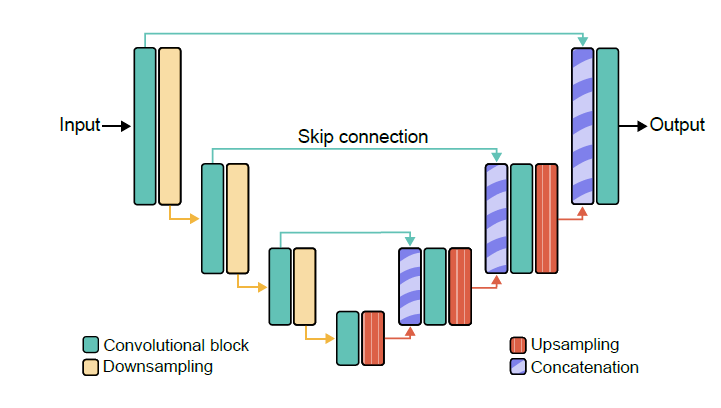

Används ofta för att göra så kallad "semantisk segmentering", dvs associera varje pixel i en bild till en viss klass

### Exempel
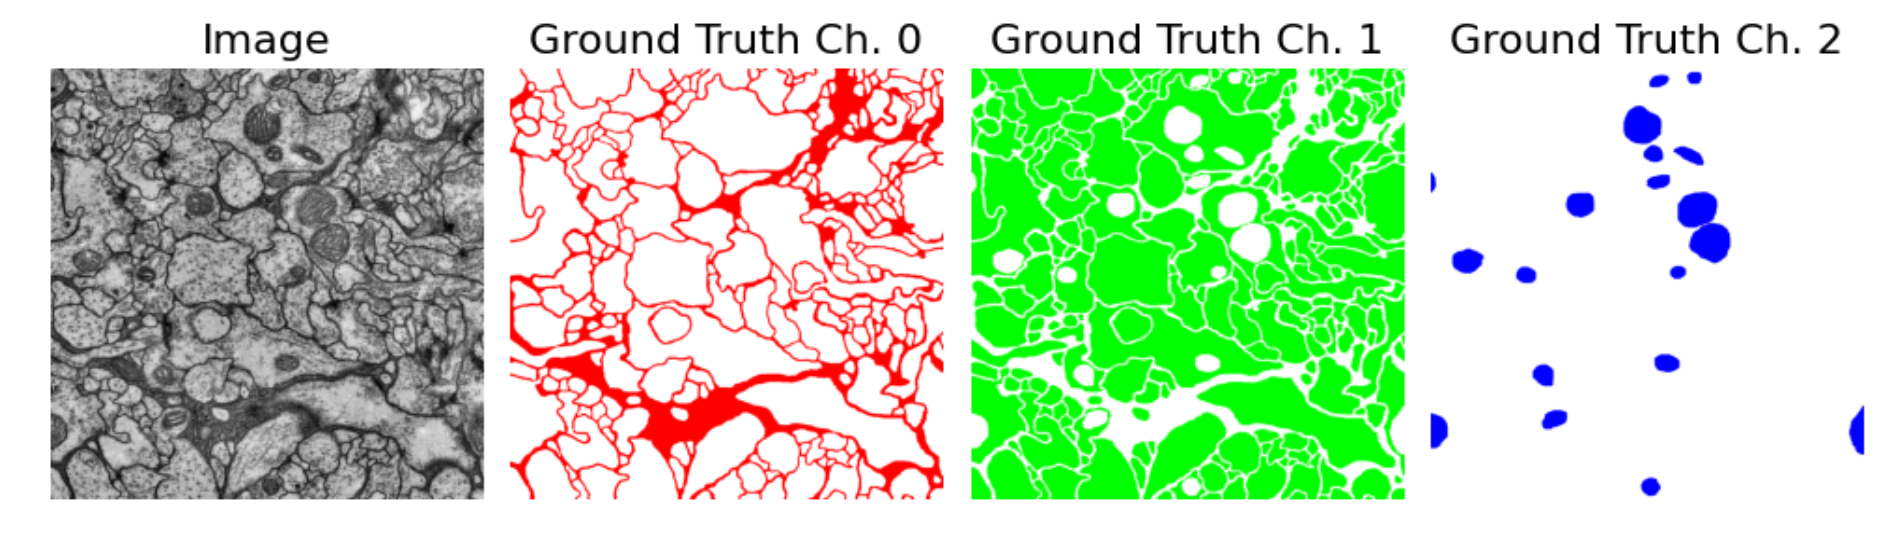

### Minimal implementation

In [ ]:
class Encoder2DConv(nn.Module):
    def __init__(self):
        super(Encoder2DConv, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3))
    def forward(self,x):
        return self.encoder(x)


In [ ]:
class Decoder2Dconv(nn.Module):
    def __init__(self):
        super(Decoder2DConv, self).__init__()
        self.decoder = nn.Sequential(nn.ConvTranspose2d(64, 32, kernel_size=3),  
            nn.ReLU(),
            nn.ConvTranspose2d(64, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.decoder(x)


In [ ]:
class UNet(nn.Module):
    def __init__(self, encoder, decoder):
        super(UNet,self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.bottleneck = nn.ConvTranspose2d(64,64,kernel_size=3, padding=1, output_padding=1)
        
    def forward(self,x):
        acts = []
        for (i, block) in enumerate(self.encoder):
            x = block(x)
            if i%2 == 1:
                acts.append(x)
        x = self.bottleneck(x)
        k=1
        for (i,block) in enumerate(self.decoder):
            x=block(x)
            if i%2 == 1:
                x = torch.Cat([x,acts[-k]])
                k=k+1
        return x

#### Unets är basen för i princip all generativ bild-AI

In [1]:
import torch.nn as nn
encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3))

In [2]:
for block in encoder:
    print(block)

Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
ReLU()
Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
ReLU()
Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))


In [5]:
encoder[1]

ReLU()

## Fortsättning för mer avancerad maskininlärning

<img src="../images/popular_deep_learning_books.png" width=80%/>

* Läs vidare om olika projekt på www.kaggle.com och sök runt på www.github.com.
* Följ exempel på https://pytorch.org/tutorials.
* https://www.gu.se/studera/hitta-utbildning?hits=40&q=maskininl%C3%A4rning
